
Let's see some examples demonstrating that some hypothese are required for the Frobenius-Perron theorem.

We expect that diagrams which are not strongly connected and diagrams which are not acyclic might fail to satisfy the conclusion of Frobenius-Perron.

# acyclic 
Consider a *cycle*

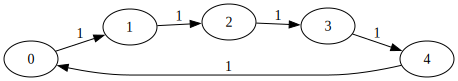

In [1]:
import numpy as np
import numpy.linalg as npl
from graphviz import Digraph 

def cycle(n=5,labels=None):
    if labels==None:
        labels= n*[1]
    cyc = Digraph()
    cyc.attr(rankdir='LR')
    I = list(range(n))

    for i in I:
        cyc.node(f"{i}")

    for i in I:
        cyc.edge(f"{i}",f"{np.mod(i+1,n)}",f"{labels[i]}")

    return cyc
    
cycle()

What is the corresponding matrix $P$?

Well, we can represent the a graph by a dictionary whose keys are pairs `(a,b)` and whose value is the probability of the corresponding state transition.

In [3]:
cd = { (n,(n+1) % 5):1 for n in range(5) }
cd

{(0, 1): 1, (1, 2): 1, (2, 3): 1, (3, 4): 1, (4, 0): 1}

In [10]:

def mat(dict):
    return np.array([[dict[(i,j)] if (i,j) in dict else 0 
                      for j in range(5)] 
                     for i in range(5)])

M=mat(cd)
M

array([[0, 1, 0, 0, 0],
       [0, 0, 1, 0, 0],
       [0, 0, 0, 1, 0],
       [0, 0, 0, 0, 1],
       [1, 0, 0, 0, 0]])

In [5]:
import numpy.linalg as npl
e_vals, e_vects = npl.eig(M)
e_vals

array([-0.80901699+0.58778525j, -0.80901699-0.58778525j,
        0.30901699+0.95105652j,  0.30901699-0.95105652j,
        1.        +0.j        ])

In [9]:
import numpy
[ numpy.abs(x) for x in e_vals ]

[np.float64(0.9999999999999994),
 np.float64(0.9999999999999994),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(0.9999999999999998)]

Adding an extra edge `4 -> 4` fixes the problem!

In [12]:
acd = { (n,(n+1) % 5):1 for n in range(5) }
acd[(4,4)] = .5
acd[(4,0)]= .5
acd

{(0, 1): 1, (1, 2): 1, (2, 3): 1, (3, 4): 1, (4, 0): 0.5, (4, 4): 0.5}

In [14]:
Ma=mat(acd)
Ma

array([[0. , 1. , 0. , 0. , 0. ],
       [0. , 0. , 1. , 0. , 0. ],
       [0. , 0. , 0. , 1. , 0. ],
       [0. , 0. , 0. , 0. , 1. ],
       [0.5, 0. , 0. , 0. , 0.5]])

In [16]:
ae_vals,ae_vecs = npl.eig(Ma)
ae_vals

array([ 1.        +0.j        ,  0.37103484+0.80377194j,
        0.37103484-0.80377194j, -0.62103484+0.50229651j,
       -0.62103484-0.50229651j])

In [18]:
#[ float(abs(x)) for x in ae_vals ]
[ abs(x) for x in ae_vals ]

[np.float64(0.9999999999999989),
 np.float64(0.8852774620837582),
 np.float64(0.8852774620837582),
 np.float64(0.7987402949603679),
 np.float64(0.7987402949603679)]

# Failure of "strongly connected" condition

Here is a diagram with 3 nodes which is not strongly connected.

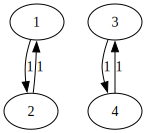

In [19]:

from itertools import product

h = Digraph()

h.edge("1","2","1")
h.edge("2","1","1")
h.edge("3","4","1")
h.edge("4","3","1")
h

The transition matrix is given by:

In [20]:
B =np.array([[0,1,0,0],
             [1,0,0,0],
             [0,0,0,1],
             [0,0,1,0]])

B

array([[0, 1, 0, 0],
       [1, 0, 0, 0],
       [0, 0, 0, 1],
       [0, 0, 1, 0]])

In [21]:
b_evals, be_vecs = np.linalg.eig(B)

b_evals

array([ 1., -1.,  1., -1.])

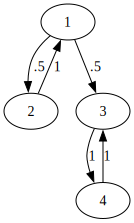

In [22]:

from itertools import product

hh = Digraph()

hh.edge("1","2",".5")
hh.edge("2","1","1")
hh.edge("3","4","1")
hh.edge("4","3","1")
hh.edge("1","3",".5")

hh

In [24]:
BB =np.array([[0,1,0,0],
             [.5,0,0,0],
             [.5,0,0,1],
             [0,0,1,0]])

BB


array([[0. , 1. , 0. , 0. ],
       [0.5, 0. , 0. , 0. ],
       [0.5, 0. , 0. , 1. ],
       [0. , 0. , 1. , 0. ]])

In [25]:
bb_evals, bbe_vecs = np.linalg.eig(BB)

bb_evals

array([-1.        , -0.70710678,  1.        ,  0.70710678])

# Example: weather on a strange planet

  On Planet X, the weather is strangely predictable: the weather is
  always either sunny, rainy, foggy or snowy. If it rains today, its
  sunny tomorrow. If it is sunny today, its rainy tomorrow. If its
  foggy today, its not sunny tomorrow. Finally, the weather is never
  the same two days in a row. Apart from these rules, the weather is
  completely random, in that if e.g. its foggy today it is equally
  likely to be either rainy or snowy tomorrow. You live on Planet X
  and are trying to figure out what to wear this week, so you'd like
  to develop a model for the weather.


This system is in fact a *Markov Process*.

The system is governed by a transition diagram for which the
probabilities on the outgoing edges from each node sum
to 1. Thus, the system is a *Markov process*.
	  
We describe the *transition diagram*. It has 4 nodes: `sunny`,
`rainy`, `foggy` and `snowy`. We are going to draw the diagram
using `graphviz` so we describe the probabilities as a python
dictionary:
	  


In [27]:
import pprint
      
weather = [ 'sunny', 'rainy', 'foggy', 'snowy' ]

transitions = {
  ('rainy', 'sunny'): 1,
  ('sunny', 'rainy'): 1,
   **{ ('foggy',w): 1/2 for w in weather if w != 'sunny' and w != 'foggy' },
   **{ ('snowy',w): 1/3 for w in weather if w != 'snowy' }
   }
pprint.pp(transitions)

{('rainy', 'sunny'): 1,
 ('sunny', 'rainy'): 1,
 ('foggy', 'rainy'): 0.5,
 ('foggy', 'snowy'): 0.5,
 ('snowy', 'sunny'): 0.3333333333333333,
 ('snowy', 'rainy'): 0.3333333333333333,
 ('snowy', 'foggy'): 0.3333333333333333}


Now let's create the transition diagram:

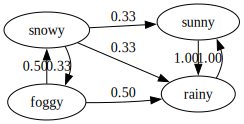

In [28]:
from graphviz import Digraph

dot = Digraph()
dot.attr(rankdir='LR')
         
with dot.subgraph() as c:
    c.attr(rank='same')
    c.node('rainy')
    c.node('sunny')
with dot.subgraph() as c:
    c.attr(rank='same')
    c.node('foggy')
    c.node('snowy')
          
from itertools import product
         
for (v1,v2) in product(weather,weather):
    if (v1,v2) in transitions.keys():
        dot.edge(v1,v2,f"{transitions[(v1,v2)]:.02f}")
#dot.format='png'              
#dot.render('PS06--weather')
dot

And we create the transition matrix:

In [29]:
import numpy as np
import numpy.linalg as npl

def transition_prob(v,w,transitions_dict):
    # get the probability for the transition v-->w
    if (v,w) in transitions_dict.keys():
        return transitions_dict[(v,w)]
    else:
        return 0

p = np.array([[ transition_prob(v,w,transitions)
                for v in weather]
              for w in weather ])

pprint.pp(p)


array([[0.        , 1.        , 0.        , 0.33333333],
       [1.        , 0.        , 0.5       , 0.33333333],
       [0.        , 0.        , 0.        , 0.33333333],
       [0.        , 0.        , 0.5       , 0.        ]])


The hypothesis of the Frobenius-Perron theorem do not hold.
The transition diagram is not **strongly connected**. For example,
there is no path from the node `sunny` to the node `foggy`.

Because the conclusion of the Frobenius-Perron theorem is not known to hold,
it is possible that `p` has more than one eigenvalue with absolute value 1.
In that case, power iteration will not help to compute the greatest eigenvector.

Let's look at the eigenvalues and eigenvectors:

In [30]:
import pprint 
import numpy as np
import numpy.linalg as npl 

vals,vecs = npl.eig(p)
pprint.pp(vals)

array([ 1.        , -1.        ,  0.40824829, -0.40824829])


Indeed, `p` has eigenvalues 1 and -1, so eigenvectors can't help describe power iteration effectively.

If `v` is an eigenvector with eigenvalue -1, then
`npl.matrix_power(p,n) @ v == v` or `-v` depending on the parity of
`n`.
    
So the long-term behavior of *powers of `p`* fails to stabilize,
so we do not expect power iteration to be an effective way of
computing the greatest eigenvector.


Suppose that the "weather rules" change so that if its sunny
today, it is equally likely to be snowy or rainy tomorrow. 

We first update the transition probabilities to reflect the new weather rules:

In [32]:
new_transitions = {
      ('rainy', 'sunny'): 1,
      ('sunny', 'rainy'): 1/2,
      ('sunny', 'snowy'): 1/2,
       **{ ('foggy',w): 1/2 for w in weather if w != 'sunny'
          and w != 'foggy' },
       **{ ('snowy',w): 1/3 for w in weather if w != 'snowy' }
      }
pprint.pp(new_transitions)


{('rainy', 'sunny'): 1,
 ('sunny', 'rainy'): 0.5,
 ('sunny', 'snowy'): 0.5,
 ('foggy', 'rainy'): 0.5,
 ('foggy', 'snowy'): 0.5,
 ('snowy', 'sunny'): 0.3333333333333333,
 ('snowy', 'rainy'): 0.3333333333333333,
 ('snowy', 'foggy'): 0.3333333333333333}


We get a new diagram as follows:

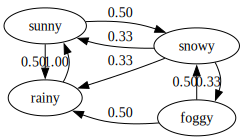

In [33]:
new_dot = Digraph(format='png')
new_dot.attr(rankdir='LR')
        
with new_dot.subgraph() as c:
      c.attr(rank='same')
      c.node('rainy')
      c.node('sunny')
with new_dot.subgraph() as c:
      c.attr(rank='same')
      c.node('foggy')
      c.node('snowy')
         
for (v1,v2) in product(weather,weather):
    if (v1,v2) in new_transitions.keys():
         new_dot.edge(v1,v2,f"{new_transitions[(v1,v2)]:.02f}")
new_dot

And we get a new transition matrix `q`.


In [35]:
q = np.array([[ transition_prob(v,w,new_transitions)
                      for v in weather]
              for w in weather ])
pprint.pp(q)


array([[0.        , 1.        , 0.        , 0.33333333],
       [0.5       , 0.        , 0.5       , 0.33333333],
       [0.        , 0.        , 0.        , 0.33333333],
       [0.5       , 0.        , 0.5       , 0.        ]])


We observe that in this case, the transition diagram is *strong
connected*.  Moreover, it is also acyclic e.g. because there are
cycles of length two (`snowy --> foggy --> snowy` for example) as
well as cycles of length three (`sunny --> snowy --> rainy -->
sunny`).  Since `gcd(2,3) = 1` there only natural number dividing
all cycle lengths is 1.
	  
Thus the Frobenius Perron Theorem holds. It promises that `q` has
eigenvalue 1 with multiplicity 1. If `v` is an eigenvector with
eigenvalue 1, normalized so that `v` is a probability vector, then
we know that `npl.matrix_power(p,n)` converges as $n \to \infty$
to the matrix `B` with 4 columns equal to the vector `v`.

We can observe this phenomenon by compute "big" powers of `q`:

In [36]:
npl.matrix_power(q,100)

array([[0.38461538, 0.38461538, 0.38461538, 0.38461538],
       [0.30769231, 0.30769231, 0.30769231, 0.30769231],
       [0.07692308, 0.07692308, 0.07692308, 0.07692308],
       [0.23076923, 0.23076923, 0.23076923, 0.23076923]])

Let's check the eigenvalues/eigenvectors:

In [37]:
vals,vecs = npl.eig(q)  
vals


array([ 1.00000000e+00, -7.88675135e-01, -2.11324865e-01,  3.36786272e-18])

In this case, as promised by Frobenius-Perron, there is exactly
one eigenvalue with absolute value 1. All other eigenvalues $\lambda$
have $|\lambda| < 1$.
	  
Note that after normalizing, the eigenvector `vecs[:,0]` is close to the columns of the 
matrix $q^{100}$ we computed above:


In [21]:
# get the eigenvector computed by numpy for eigenvalue 1
# remember that it is the first *column* of the matrix ev,
# not the first row...!!
ev = vecs[:,0]

# normalize to make a probability vector
c = np.array([1,1,1,1]) @ ev  # c is the sum of the entries of ev
p_ev = (1/c)*ev               # the entries of p_ev sum to 1
	  
p_ev

array([0.38461538, 0.30769231, 0.07692308, 0.23076923])

In [23]:
weather

['sunny', 'rainy', 'foggy', 'snowy']

The entries of `p_ev` describe the "long term probabilities" of weather under this new configuration.

For example, the steady-state probability of `sunny` is about 38%, and the steady state probability of `rainy` is about 30%.